In [8]:
import sys
import os
os.chdir("/home/karlandersson/Programming/MasterThesisProject")
print(os.getcwd())

/home/karlandersson/Programming/MasterThesisProject


In [9]:
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from matplotlib.colors import LinearSegmentedColormap
import numpy as np

from pathlib import Path

from utils.solver import Solver
from utils.iso_reactor_utils import generate_config, generate_config_seq
from utils.interpolator import OpenMCTallyGridSurrogate

from coupled.vapour_reactor import VapourReactor
from coupled.iso_reactor import Reactor

In [10]:
with open("./data/reactor_data.json", "r") as f:
    data = json.load(f)
    data["HeatPipe"]["material"]["h_cond"] = 550

MODEL_PATH = Path("./utils/rgi_surrogate.joblib")
interpolator_model = OpenMCTallyGridSurrogate()
interpolator_model = interpolator_model.load(MODEL_PATH)

In [11]:
Ns = [15, 65, 40]
cfg = generate_config(data, *Ns)

iso_reactor      = Reactor(cfg)
vap_reactor_800  = VapourReactor(cfg)
vap_reactor      = VapourReactor(cfg)
vap_reactor_full = VapourReactor(cfg)

vap_reactor.heatpipe.solid.k_temperature = 1100

vap_reactor_full.set_interpolator_model(interpolator_model)
vap_reactor_full.set_variable_k(True)

solver_iso = Solver([iso_reactor])
solver_vap = Solver([vap_reactor_800, vap_reactor, vap_reactor_full], iterate = True)
solver_iso.fsolve()
solver_vap.fsolve()

Mesh warning: N_Z changed from 40 to 46
Mesh warning: Fuel pin N_Z changed from 18 to 30
Mesh warning: Neutronics N_Z changed from 18 to 30
fsolve message: The solution converged.
Solving Heat pipe initial values
fsolve message: The solution converged.
Running iteration 1 ...
fsolve message: The solution converged.
Running iteration 2 ...
fsolve message: The solution converged.
Running iteration 3 ...
fsolve message: The solution converged.


In [12]:
plt.rcParams["font.size"] = 30
plt.rcParams["font.family"] = "cm"
plt.rcParams["text.usetex"] = True

colors = {
    "blue": "#0077BB",
    "cyan": "#33BBEE",
    "teal": "#009988",
    "orange": "#EE7733",
    "red": "#CC3311",
    "magenta": "#EE3377",
    "grey": "#BBBBBB"
}

cmap_orange = LinearSegmentedColormap.from_list(
    "blue_to_white",
    [colors["orange"], "white"]
)


In [18]:
(T_hp_iso, T_FP_iso, (phi_n_g_iso, k_iso)) = solver_iso.solutions[0]
((T_solid_vap, u_v, T_v), T_FP_vap, (phi_n_g_vap, k_vap)) = solver_vap.solutions[1]
((T_solid_vap_full, u_v_full, T_v_full), T_FP_vap_full, (phi_n_g_vap_full, k_vap_full)) = solver_vap.solutions[2]

z_hp = iso_reactor.heat_pipe_thermal_model.Z
z_fp = np.linspace(0, cfg.FP.geometry.l, cfg.FP.mesh.N_Z)

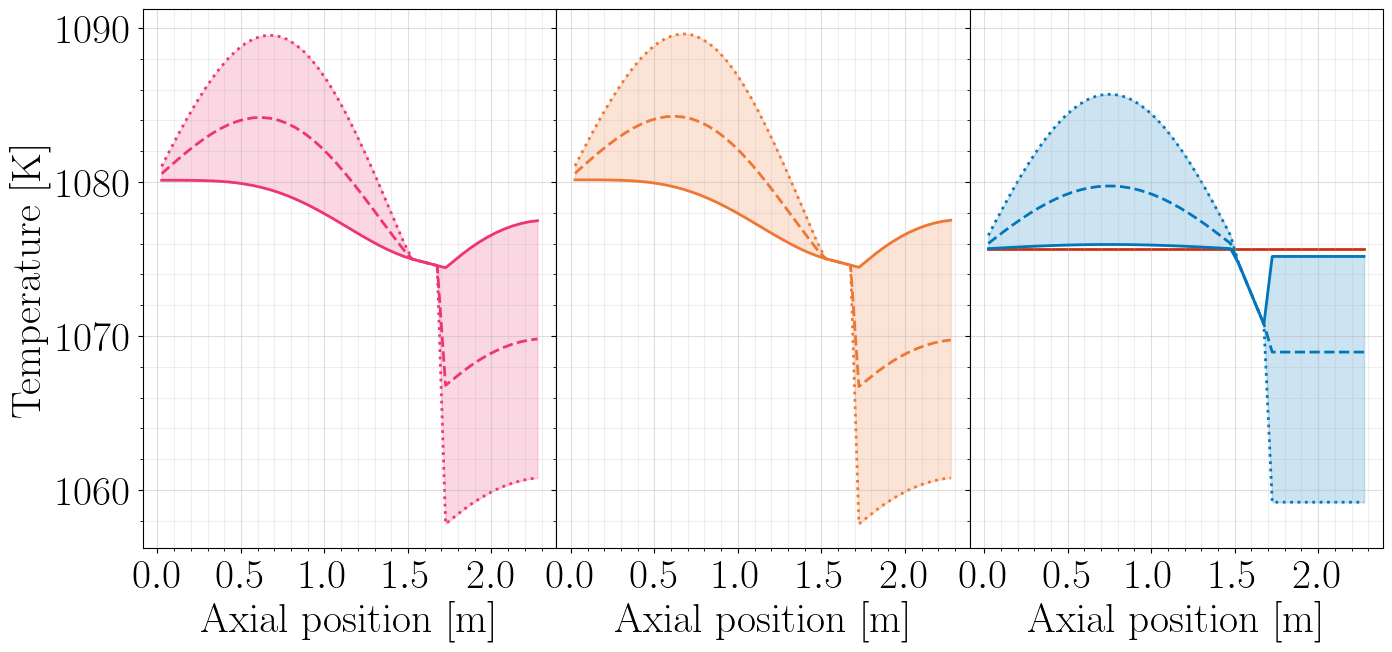

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(16, 7),
    sharey=True,
    gridspec_kw={"wspace": 0.0}
)

# Discretised vapour reactor
ax1.plot(z_hp, T_solid_vap_full[:, -1],                   color=colors["magenta"], lw=2, linestyle=":" , zorder=1, label=r"$Outer T_z$")
ax1.plot(z_hp, T_solid_vap_full[:, cfg.HP.mesh.N_R // 2], color=colors["magenta"], lw=2, linestyle="--", zorder=2, label=r"$Middle T_z$")
ax1.plot(z_hp, T_v_full,                                  color=colors["magenta"], lw=2, linestyle="-" , zorder=3, label=r"$Vapour T_z$")

# Discretised vapour reactor
ax2.plot(z_hp, T_solid_vap[:, -1],                   color=colors["orange"], lw=2, linestyle=":" , zorder=1, label=r"Outer $T_z$")
ax2.plot(z_hp, T_solid_vap[:, cfg.HP.mesh.N_R // 2], color=colors["orange"], lw=2, linestyle="--", zorder=2, label=r"Middle $T_z$")
ax2.plot(z_hp, T_v,                                  color=colors["orange"], lw=2, linestyle="-" , zorder=3, label=r"Vapour $T_z$")

# Isothermal vapour reactor
ax3.plot(z_hp, T_hp_iso[0][:, -1],                   color=colors["blue"], lw=2, linestyle=":" , zorder=1)
ax3.plot(z_hp, T_hp_iso[0][:, cfg.HP.mesh.N_R // 2], color=colors["blue"], lw=2, linestyle="--", zorder=2)
ax3.plot(z_hp, T_hp_iso[0][:, 0],                    color=colors["blue"], lw=2, linestyle="-" , zorder=3)

# Isothermal vapour reference temperature
ax3.plot(z_hp, np.full(z.shape, T_hp_iso[-1]), color=colors["red"], lw=2, zorder=0)

ax1.fill_between(z_hp, T_solid_vap_full[:, -1], T_v_full, color=colors["magenta"], alpha=0.2)
ax2.fill_between(z_hp, T_solid_vap[:, -1], T_v, color=colors["orange"], alpha=0.2)
ax3.fill_between(z_hp, T_hp_iso[0][:, -1], T_hp_iso[0][:, 0], color=colors["blue"], alpha=0.2)

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()

ax1.set_ylabel("Temperature [K]")
ax1.set_xlabel("Axial position [m]")
ax2.set_xlabel("Axial position [m]")
ax3.set_xlabel("Axial position [m]")

ax1.grid(which="major", alpha=0.4)
ax1.grid(which="minor", alpha=0.2)
ax2.grid(which="major", alpha=0.4)
ax2.grid(which="minor", alpha=0.2)
ax3.grid(which="major", alpha=0.4)
ax3.grid(which="minor", alpha=0.2)

# ax1.set_xlim((np.min(z), np.max(z)))
# ax2.set_xlim((np.min(z), np.max(z)))
# ax3.set_xlim((np.min(z), np.max(z)))

ax1.xaxis.set_major_locator(MultipleLocator(0.5))
ax2.xaxis.set_major_locator(MultipleLocator(0.5))
ax3.xaxis.set_major_locator(MultipleLocator(0.5))

# Hide labels on the right plot, but keep ticks for the grid
ax2.tick_params(axis="y", labelleft=False)
ax3.tick_params(axis="y", labelleft=False)

plt.show()

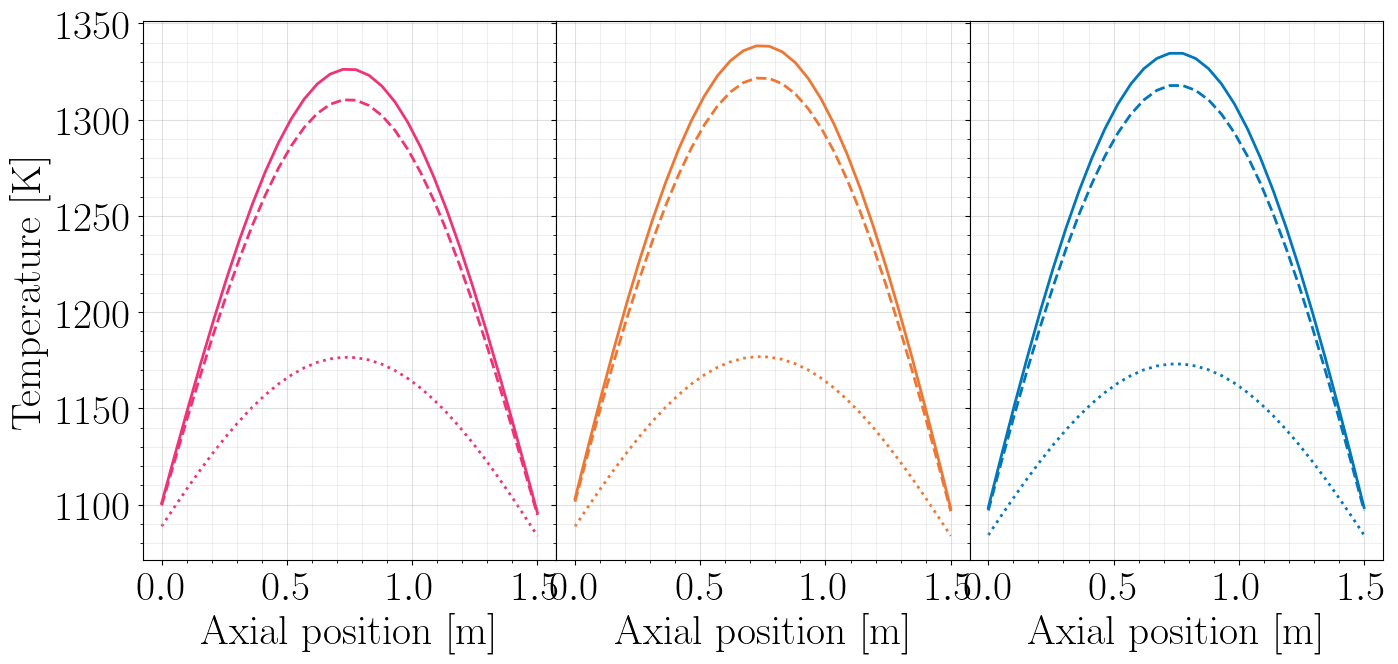

In [25]:
fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize = (16, 7),
    sharey = True,
    gridspec_kw = {"wspace": 0.0}
)

# Discretised vapour reactor
ax1.plot(z_fp, T_FP_vap_full[:, -1],                   color=colors["magenta"], lw=2, linestyle=":" , zorder=1)
ax1.plot(z_fp, T_FP_vap_full[:, cfg.HP.mesh.N_R // 2], color=colors["magenta"], lw=2, linestyle="--", zorder=2)
ax1.plot(z_fp, T_FP_vap_full[:, 0],                    color=colors["magenta"], lw=2, linestyle="-" , zorder=3)

# Discretised vapour reactor
ax2.plot(z_fp, T_FP_vap[:, -1],                   color=colors["orange"], lw=2, linestyle=":" , zorder=1)
ax2.plot(z_fp, T_FP_vap[:, cfg.HP.mesh.N_R // 2], color=colors["orange"], lw=2, linestyle="--", zorder=2)
ax2.plot(z_fp, T_FP_vap[:, 0],                    color=colors["orange"], lw=2, linestyle="-" , zorder=3)

# Isothermal vapour reactor
ax3.plot(z_fp, T_FP_iso[:, -1],                   color=colors["blue"], lw=2, linestyle=":" , zorder=1)
ax3.plot(z_fp, T_FP_iso[:, cfg.HP.mesh.N_R // 2], color=colors["blue"], lw=2, linestyle="--", zorder=2)
ax3.plot(z_fp, T_FP_iso[:, 0],                    color=colors["blue"], lw=2, linestyle="-" , zorder=3)

ax1.minorticks_on()
ax2.minorticks_on()
ax3.minorticks_on()

ax1.set_ylabel("Temperature [K]")
ax1.set_xlabel("Axial position [m]")
ax2.set_xlabel("Axial position [m]")
ax3.set_xlabel("Axial position [m]")

ax1.grid(which="major", alpha=0.4)
ax1.grid(which="minor", alpha=0.2)
ax2.grid(which="major", alpha=0.4)
ax2.grid(which="minor", alpha=0.2)
ax3.grid(which="major", alpha=0.4)
ax3.grid(which="minor", alpha=0.2)

ax1.xaxis.set_major_locator(MultipleLocator(0.5))
ax2.xaxis.set_major_locator(MultipleLocator(0.5))
ax3.xaxis.set_major_locator(MultipleLocator(0.5))

# Hide labels on the right plot, but keep ticks for the grid
ax2.tick_params(axis="y", labelleft=False)
ax3.tick_params(axis="y", labelleft=False)